In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('default')
sns.set_palette("husl")

In [2]:
# Load the datasets
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')
sample_submission = pd.read_csv('sample_submission.csv')

print(f"Training data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}")
print(f"Sample submission shape: {sample_submission.shape}")

Training data shape: (700000, 26)
Test data shape: (300000, 25)
Sample submission shape: (300000, 2)


In [3]:
# Display basic information about the dataset
print("Training Data Info:")
print(train_df.info())
print("\nFirst 5 rows:")
train_df.head()

Training Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 700000 entries, 0 to 699999
Data columns (total 26 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   id                                  700000 non-null  int64  
 1   age                                 700000 non-null  int64  
 2   alcohol_consumption_per_week        700000 non-null  int64  
 3   physical_activity_minutes_per_week  700000 non-null  int64  
 4   diet_score                          700000 non-null  float64
 5   sleep_hours_per_day                 700000 non-null  float64
 6   screen_time_hours_per_day           700000 non-null  float64
 7   bmi                                 700000 non-null  float64
 8   waist_to_hip_ratio                  700000 non-null  float64
 9   systolic_bp                         700000 non-null  int64  
 10  diastolic_bp                        700000 non-null  int64  
 11  heart_

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,...,gender,ethnicity,education_level,income_level,smoking_status,employment_status,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
0,0,31,1,45,7.7,6.8,6.1,33.4,0.93,112,...,Female,Hispanic,Highschool,Lower-Middle,Current,Employed,0,0,0,1.0
1,1,50,2,73,5.7,6.5,5.8,23.8,0.83,120,...,Female,White,Highschool,Upper-Middle,Never,Employed,0,0,0,1.0
2,2,32,3,158,8.5,7.4,9.1,24.1,0.83,95,...,Male,Hispanic,Highschool,Lower-Middle,Never,Retired,0,0,0,0.0
3,3,54,3,77,4.6,7.0,9.2,26.6,0.83,121,...,Female,White,Highschool,Lower-Middle,Current,Employed,0,1,0,1.0
4,4,54,1,55,5.7,6.2,5.1,28.8,0.90,108,...,Male,White,Highschool,Upper-Middle,Never,Retired,0,1,0,1.0


In [4]:
# Check for missing values
print("Missing values in training data:")
print(train_df.isnull().sum())
print("\nMissing values in test data:")
print(test_df.isnull().sum())

Missing values in training data:
id                                    0
age                                   0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
smoking_status                        0
employment_status                     0
family_history_diabetes               0
hypertension_history                  0
cardiov

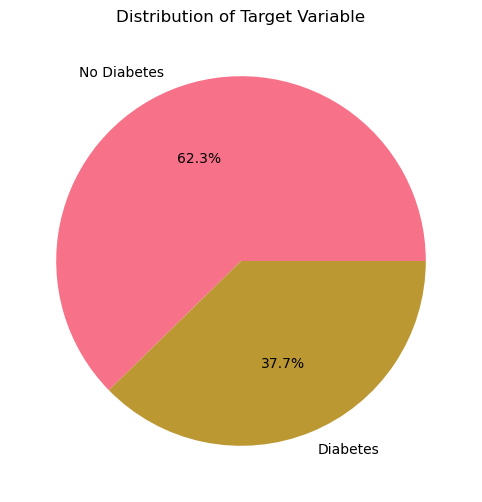

Target distribution:
diagnosed_diabetes
1.0    0.623296
0.0    0.376704
Name: proportion, dtype: float64


In [5]:
# Target variable distribution
plt.figure(figsize=(8, 6))
target_counts = train_df['diagnosed_diabetes'].value_counts()
plt.pie(target_counts.values, labels=['No Diabetes', 'Diabetes'], autopct='%1.1f%%')
plt.title('Distribution of Target Variable')
plt.show()

print(f"Target distribution:")
print(train_df['diagnosed_diabetes'].value_counts(normalize=True))

In [6]:
# Statistical summary
train_df.describe()

,id,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,bmi,waist_to_hip_ratio,systolic_bp,diastolic_bp,heart_rate,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,family_history_diabetes,hypertension_history,cardiovascular_history,diagnosed_diabetes
count,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000,700000.000000
mean,349999.500000,50.359734,2.072411,80.230803,5.963695,7.002200,6.012733,25.874684,0.858766,116.294193,75.440924,70.167749,186.818801,53.823214,102.905854,123.081850,0.149401,0.181990,0.030324,0.623296
std,202072.738554,11.655520,1.048189,51.195071,1.463336,0.901907,2.022707,2.860705,0.037980,11.010390,6.825775,6.938722,16.730832,8.266545,19.022416,24.739397,0.356484,0.385837,0.171478,0.484560
min,0.000000,19.000000,1.000000,1.000000,0.100000,3.100000,0.600000,15.100000,0.680000,91.000000,51.000000,42.000000,117.000000,21.000000,51.000000,31.000000,0.000000,0.000000,0.000000,0.000000
25%,174999.750000,42.000000,1.000000,49.000000,5.000000,6.400000,4.600000,23.900000,0.830000,108.000000,71.000000,65.000000,175.000000,48.000000,89.000000,106.000000,0.000000,0.000000,0.000000,0.000000
50%,349999.500000,50.000000,2.000000,71.000000,6.000000,7.000000,6.000000,25.900000,0.860000,116.000000,75.000000,70.000000,187.000000,54.000000,103.000000,123.000000,0.000000,0.000000,0.000000,1.000000
75%,524999.250000,58.000000,3.000000,96.000000,7.000000,7.600000,7.400000,27.800000,0.880000,124.000000,80.000000,75.000000,199.000000,59.000000,116.000000,139.000000,0.000000,0.000000,0.000000,1.000000
max,699999.000000,89.000000,9.000000,747.000000,9.900000,9.900000,16.500000,38.400000,1.050000,163.000000,104.000000,101.000000,289.000000,90.000000,205.000000,290.000000,1.000000,1.000000,1.000000,1.000000


In [7]:
# Identify categorical and numerical columns
categorical_cols = ['gender', 'ethnicity', 'education_level', 'income_level', 
                   'smoking_status', 'employment_status']
numerical_cols = [col for col in train_df.columns if col not in categorical_cols + ['id', 'diagnosed_diabetes']]

print(f"Categorical columns: {categorical_cols}")
print(f"Numerical columns: {numerical_cols}")

Categorical columns: ['gender', 'ethnicity', 'education_level', 'income_level', 'smoking_status', 'employment_status']
Numerical columns: ['age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history']


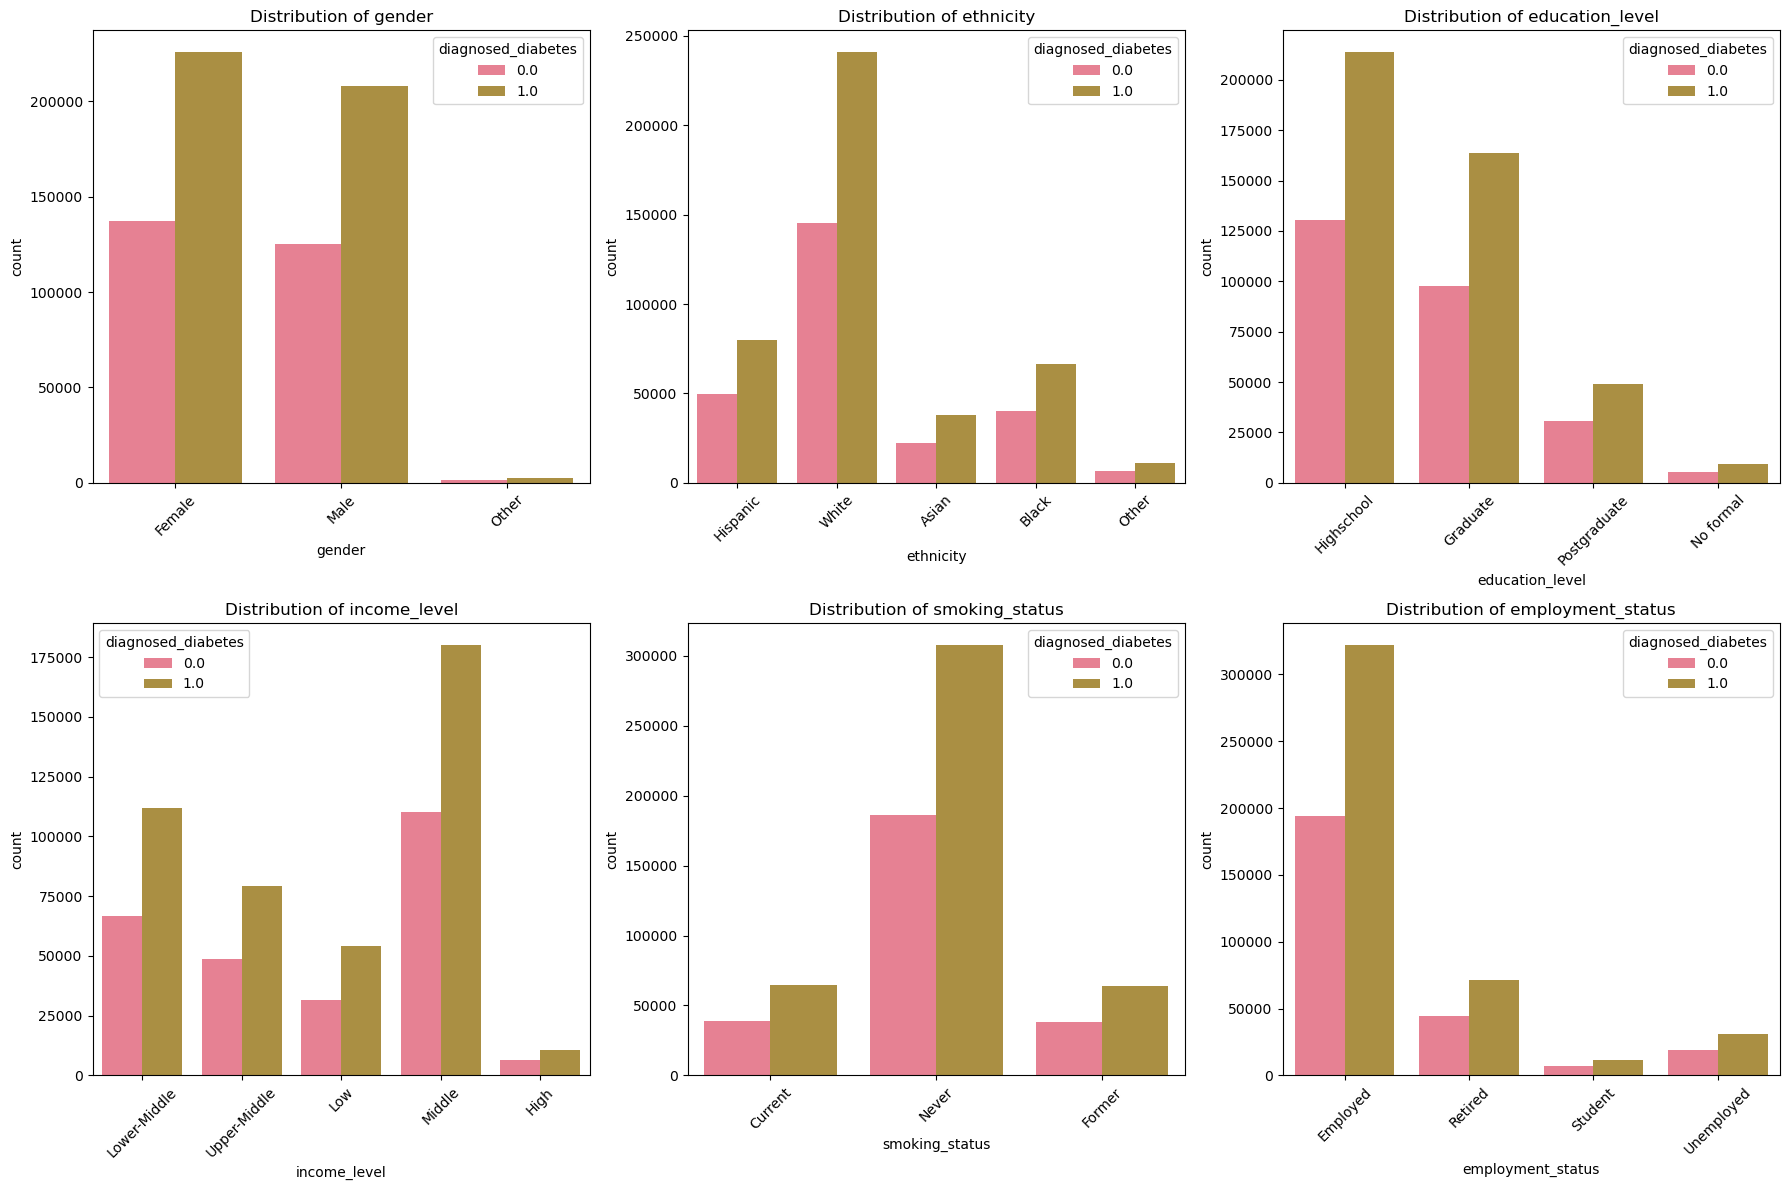

In [8]:
# Visualize categorical variables
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for i, col in enumerate(categorical_cols):
    sns.countplot(data=train_df, x=col, hue='diagnosed_diabetes', ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

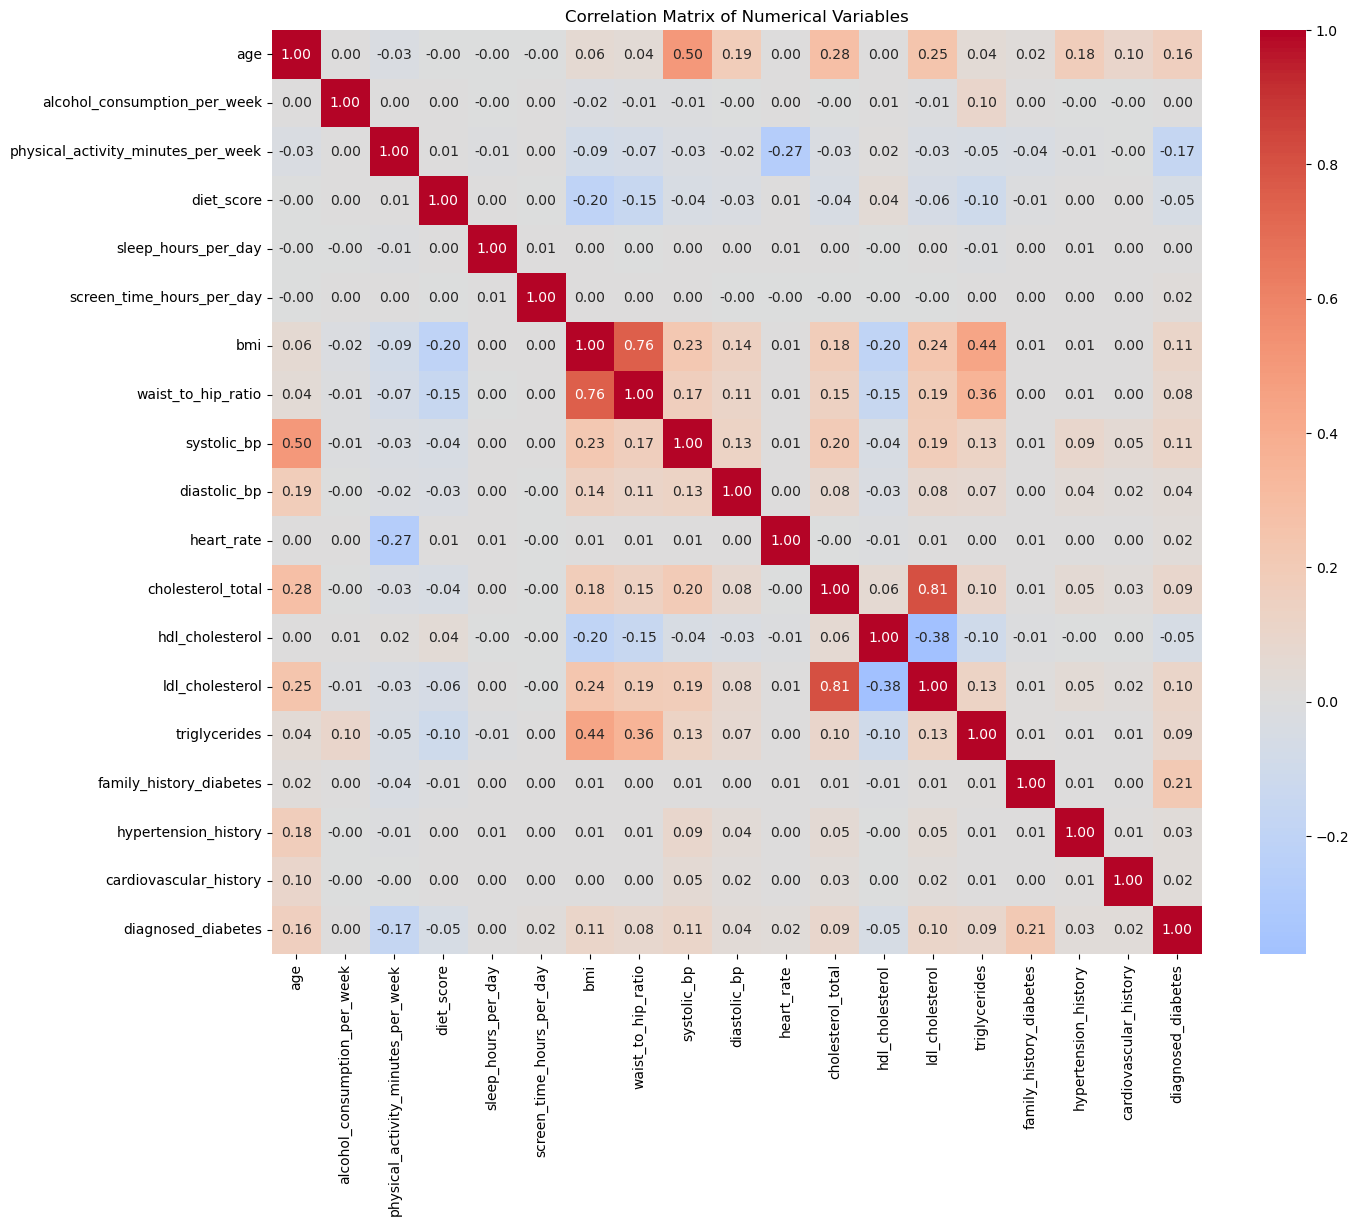

In [9]:
# Correlation matrix for numerical variables
plt.figure(figsize=(15, 12))
correlation_matrix = train_df[numerical_cols + ['diagnosed_diabetes']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix of Numerical Variables')
plt.show()

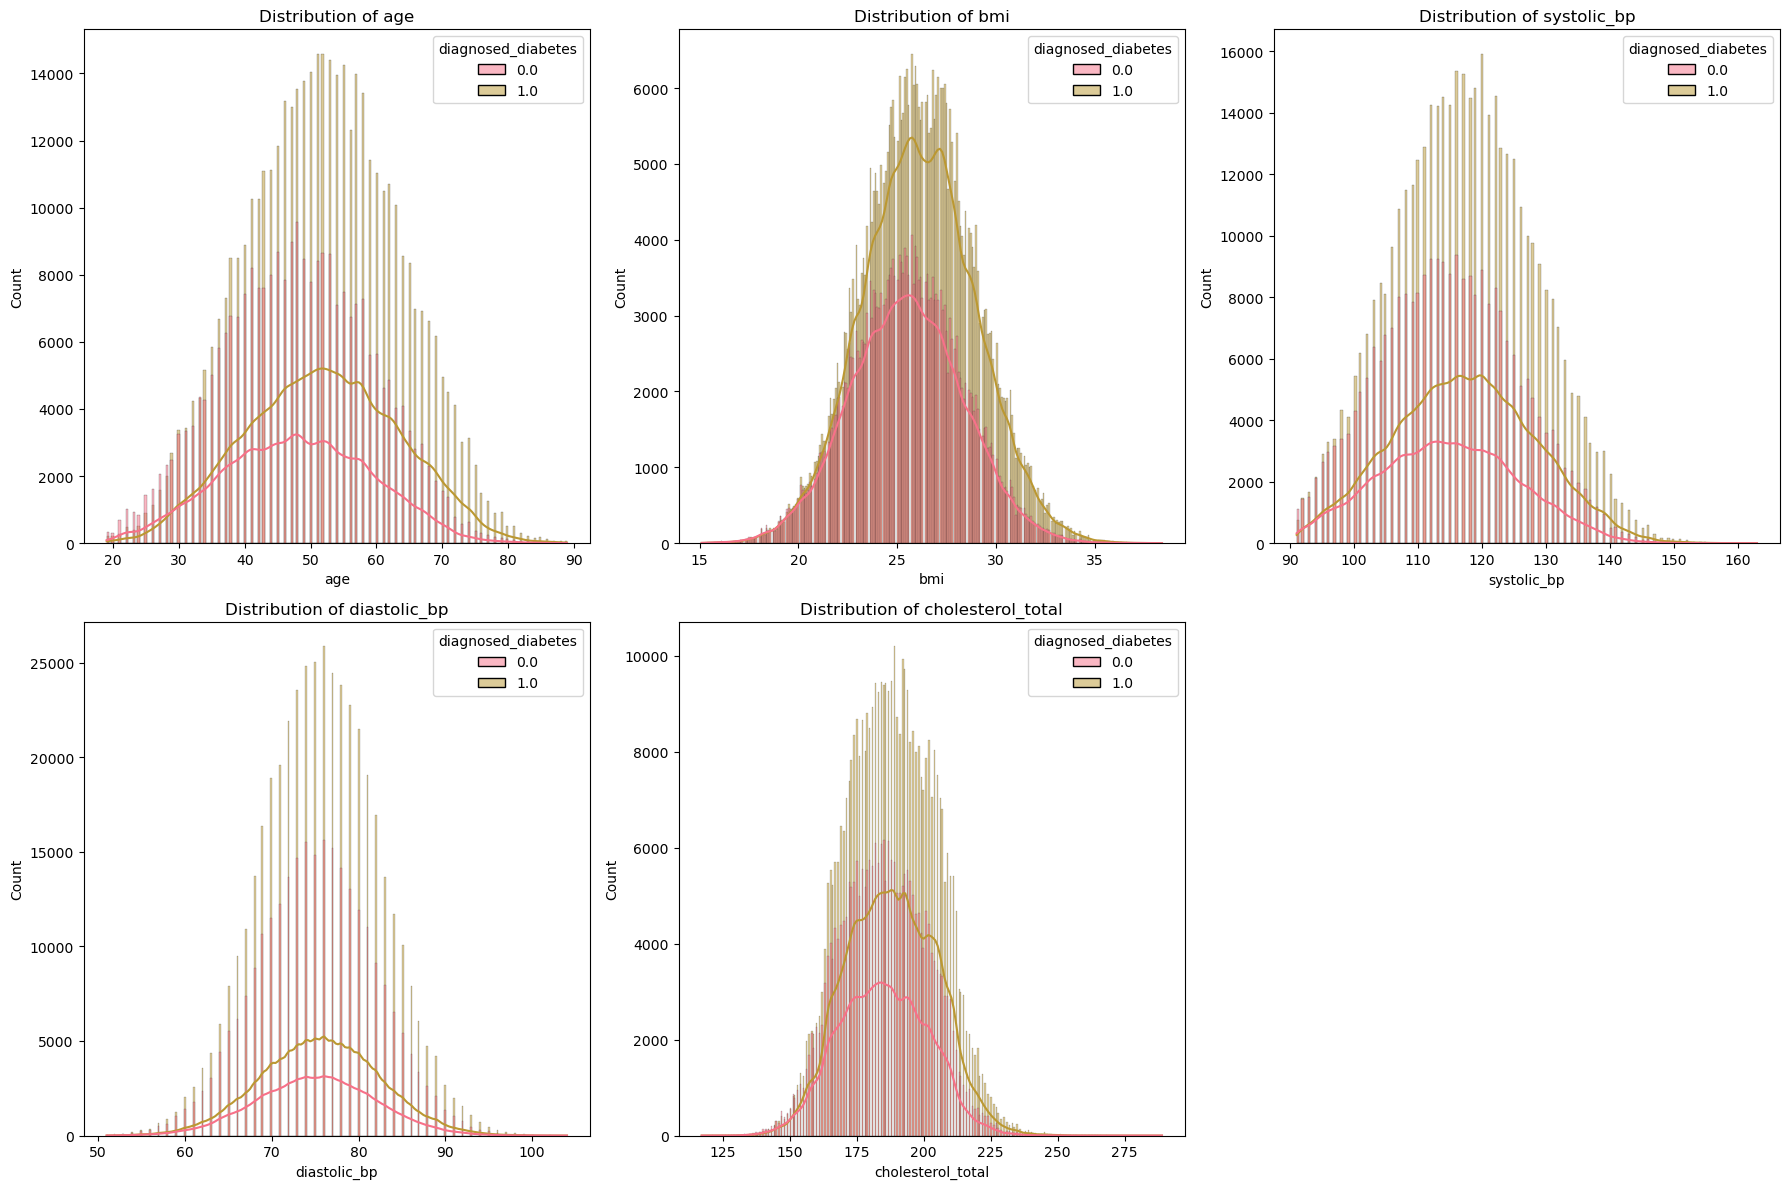

In [10]:
# Distribution of key numerical features
key_features = ['age', 'bmi', 'systolic_bp', 'diastolic_bp', 'cholesterol_total']
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for i, col in enumerate(key_features):
    sns.histplot(data=train_df, x=col, hue='diagnosed_diabetes', kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')

# Remove empty subplot
fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

## 3. Data Preprocessing

In [11]:
def preprocess_data(train_df, test_df):
    """Preprocess the training and test data"""
    # Separate features and target
    X = train_df.drop(['id', 'diagnosed_diabetes'], axis=1)
    y = train_df['diagnosed_diabetes']
    X_test = test_df.drop(['id'], axis=1)
    
    # Combine train and test for consistent encoding
    combined_df = pd.concat([X, X_test], axis=0, ignore_index=True)
    
    # Label encode categorical variables
    label_encoders = {}
    for col in categorical_cols:
        le = LabelEncoder()
        combined_df[col] = le.fit_transform(combined_df[col].astype(str))
        label_encoders[col] = le
        print(f"Encoded {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")
    
    # Split back to train and test
    X_processed = combined_df.iloc[:len(X)]
    X_test_processed = combined_df.iloc[len(X):]
    
    return X_processed, y, X_test_processed, label_encoders

# Preprocess the data
X, y, X_test, label_encoders = preprocess_data(train_df, test_df)

print(f"\nProcessed training features shape: {X.shape}")
print(f"Processed test features shape: {X_test.shape}")
print(f"Target shape: {y.shape}")

Encoded gender: {'Female': np.int64(0), 'Male': np.int64(1), 'Other': np.int64(2)}
Encoded ethnicity: {'Asian': np.int64(0), 'Black': np.int64(1), 'Hispanic': np.int64(2), 'Other': np.int64(3), 'White': np.int64(4)}
Encoded education_level: {'Graduate': np.int64(0), 'Highschool': np.int64(1), 'No formal': np.int64(2), 'Postgraduate': np.int64(3)}
Encoded income_level: {'High': np.int64(0), 'Low': np.int64(1), 'Lower-Middle': np.int64(2), 'Middle': np.int64(3), 'Upper-Middle': np.int64(4)}
Encoded smoking_status: {'Current': np.int64(0), 'Former': np.int64(1), 'Never': np.int64(2)}
Encoded employment_status: {'Employed': np.int64(0), 'Retired': np.int64(1), 'Student': np.int64(2), 'Unemployed': np.int64(3)}

Processed training features shape: (700000, 24)
Processed test features shape: (300000, 24)
Target shape: (700000,)


In [12]:
# Split data for validation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Training target distribution: {y_train.value_counts(normalize=True)}")
print(f"Validation target distribution: {y_val.value_counts(normalize=True)}")

Training set shape: (560000, 24)
Validation set shape: (140000, 24)
Training target distribution: diagnosed_diabetes
1.0    0.623296
0.0    0.376704
Name: proportion, dtype: float64
Validation target distribution: diagnosed_diabetes
1.0    0.623293
0.0    0.376707
Name: proportion, dtype: float64


In [13]:
# Initialize models
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42, max_depth=6),
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000)
}

# Scale features for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Train and evaluate models
model_results = {}
trained_models = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred_proba = model.predict_proba(X_val_scaled)[:, 1]
        y_pred = model.predict(X_val_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred_proba = model.predict_proba(X_val)[:, 1]
        y_pred = model.predict(X_val)
    
    # Calculate metrics
    auc_score = roc_auc_score(y_val, y_pred_proba)
    
    model_results[name] = {
        'AUC': auc_score,
        'predictions': y_pred,
        'probabilities': y_pred_proba
    }
    
    trained_models[name] = model
    
    print(f"{name} - AUC: {auc_score:.4f}")

# Find best model
best_model_name = max(model_results.keys(), key=lambda x: model_results[x]['AUC'])
best_model = trained_models[best_model_name]
best_auc = model_results[best_model_name]['AUC']

print(f"\nBest Model: {best_model_name} with AUC: {best_auc:.4f}")


Training Random Forest...
Random Forest - AUC: 0.6983

Training Gradient Boosting...
Gradient Boosting - AUC: 0.7190

Training Logistic Regression...
Logistic Regression - AUC: 0.6946

Best Model: Gradient Boosting with AUC: 0.7190


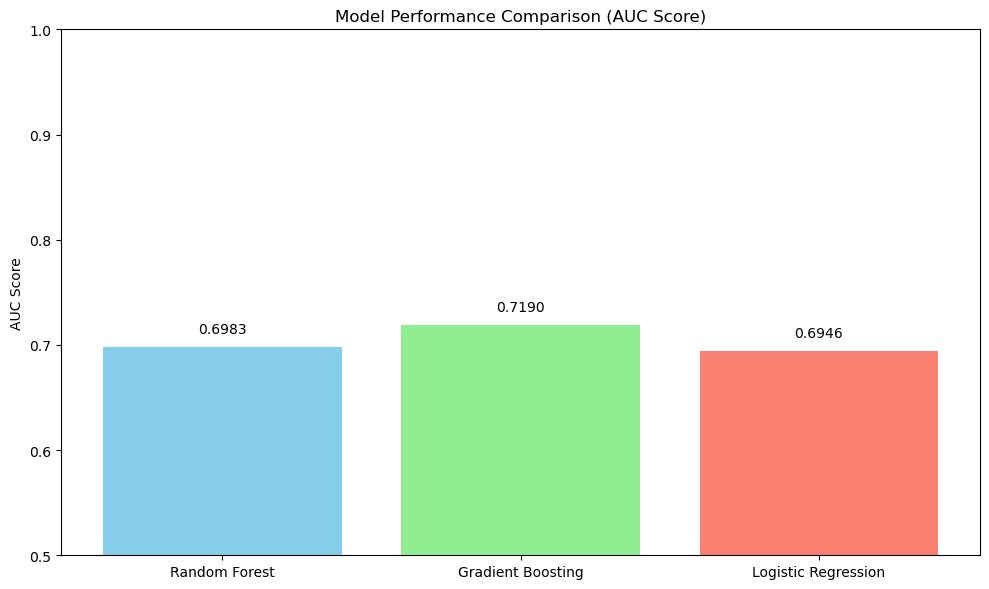

In [14]:
# Model comparison visualization
model_names = list(model_results.keys())
auc_scores = [model_results[name]['AUC'] for name in model_names]

plt.figure(figsize=(10, 6))
bars = plt.bar(model_names, auc_scores, color=['skyblue', 'lightgreen', 'salmon'])
plt.title('Model Performance Comparison (AUC Score)')
plt.ylabel('AUC Score')
plt.ylim(0.5, 1.0)

# Add value labels on bars
for bar, score in zip(bars, auc_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{score:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

Classification Report for Gradient Boosting:
              precision    recall  f1-score   support

         0.0       0.61      0.39      0.48     52739
         1.0       0.70      0.85      0.77     87261

    accuracy                           0.68    140000
   macro avg       0.66      0.62      0.62    140000
weighted avg       0.67      0.68      0.66    140000



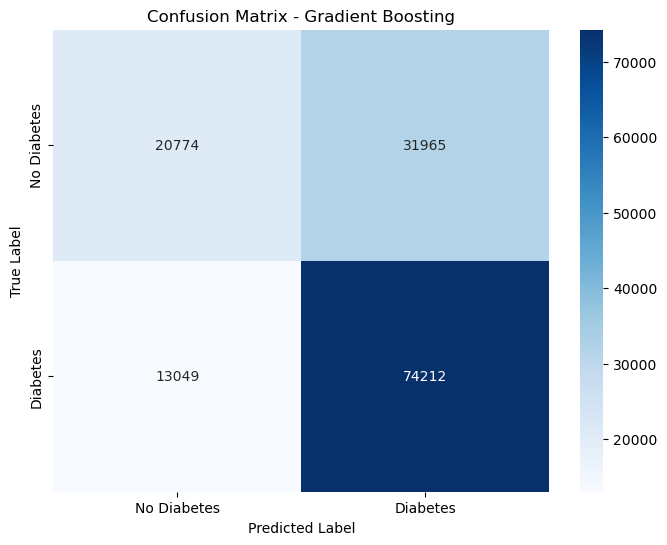

In [15]:
# Detailed evaluation of best model
best_predictions = model_results[best_model_name]['predictions']
best_probabilities = model_results[best_model_name]['probabilities']

print(f"Classification Report for {best_model_name}:")
print(classification_report(y_val, best_predictions))

# Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_val, best_predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

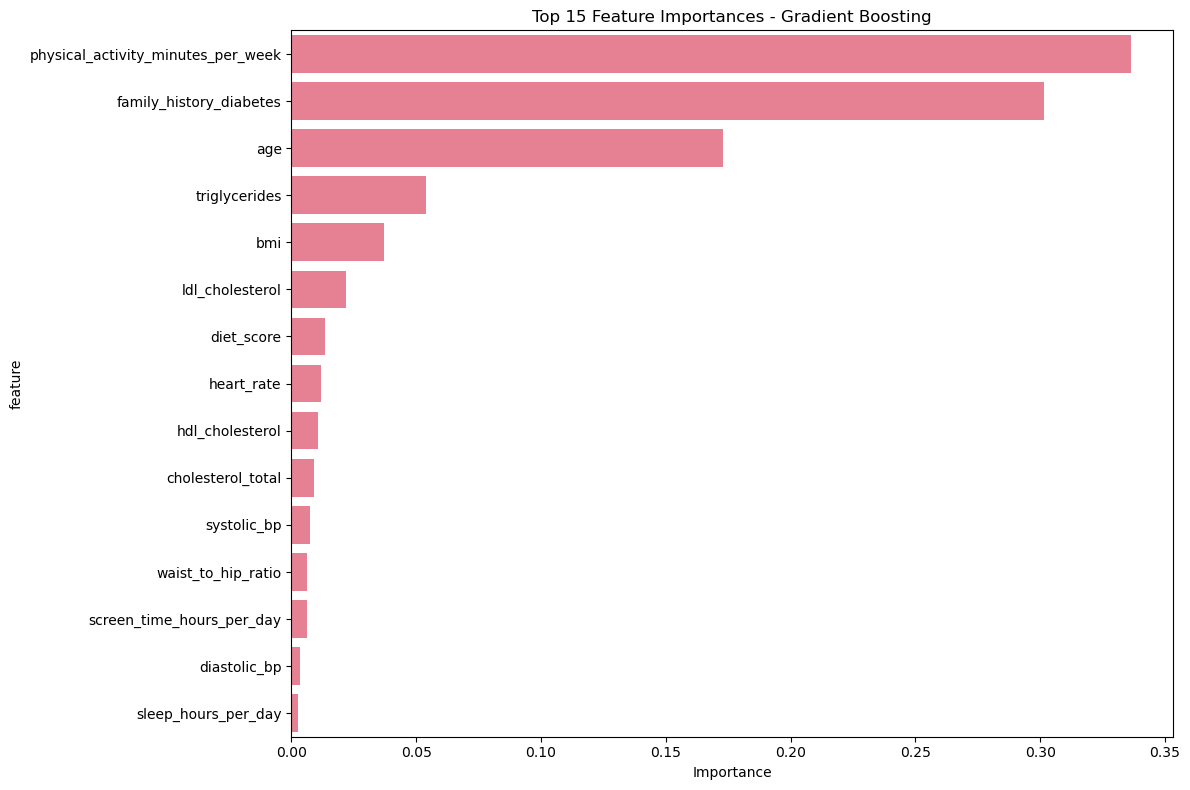

Top 10 Most Important Features:
                               feature  importance
2   physical_activity_minutes_per_week    0.336316
21             family_history_diabetes    0.301577
0                                  age    0.173037
14                       triglycerides    0.053899
6                                  bmi    0.037016
13                     ldl_cholesterol    0.022065
3                           diet_score    0.013592
10                          heart_rate    0.011729
12                     hdl_cholesterol    0.010645
11                   cholesterol_total    0.008888


In [16]:
# Feature importance for tree-based models
if best_model_name in ['Random Forest', 'Gradient Boosting']:
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    plt.figure(figsize=(12, 8))
    sns.barplot(data=feature_importance.head(15), x='importance', y='feature')
    plt.title(f'Top 15 Feature Importances - {best_model_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.show()
    
    print("Top 10 Most Important Features:")
    print(feature_importance.head(10))

In [17]:
# Generate predictions on test data
if best_model_name == 'Logistic Regression':
    X_test_scaled = scaler.transform(X_test)
    test_predictions = best_model.predict_proba(X_test_scaled)[:, 1]
else:
    test_predictions = best_model.predict_proba(X_test)[:, 1]

# Create submission dataframe
submission = pd.DataFrame({
    'id': test_df['id'],
    'diagnosed_diabetes': test_predictions
})

print(f"Submission shape: {submission.shape}")
print(f"\nPrediction Statistics:")
print(f"Min: {submission['diagnosed_diabetes'].min():.4f}")
print(f"Max: {submission['diagnosed_diabetes'].max():.4f}")
print(f"Mean: {submission['diagnosed_diabetes'].mean():.4f}")
print(f"Std: {submission['diagnosed_diabetes'].std():.4f}")

submission.head()

Submission shape: (300000, 2)

Prediction Statistics:
Min: 0.0707
Max: 0.9785
Mean: 0.6016
Std: 0.1822


,id,diagnosed_diabetes
0,700000,0.528528
1,700001,0.644599
2,700002,0.749749
3,700003,0.471526
4,700004,0.890404


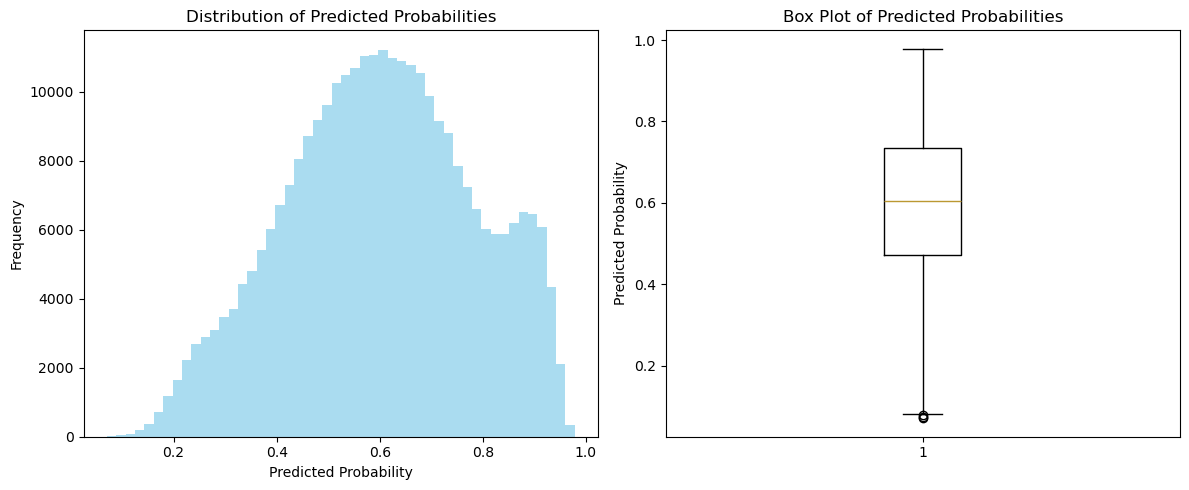

In [18]:
# Visualize prediction distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(submission['diagnosed_diabetes'], bins=50, alpha=0.7, color='skyblue')
plt.title('Distribution of Predicted Probabilities')
plt.xlabel('Predicted Probability')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.boxplot(submission['diagnosed_diabetes'])
plt.title('Box Plot of Predicted Probabilities')
plt.ylabel('Predicted Probability')

plt.tight_layout()
plt.show()

In [19]:
# Save submission file
submission.to_csv('submission.csv', index=False)
print("Submission file saved as 'submission.csv'")

# Verify submission format
print("\nSubmission file verification:")
print(f"Shape: {submission.shape}")
print(f"Columns: {list(submission.columns)}")
print(f"Data types: {submission.dtypes.to_dict()}")
print(f"Any missing values: {submission.isnull().sum().sum()}")

Submission file saved as 'submission.csv'

Submission file verification:
Shape: (300000, 2)
Columns: ['id', 'diagnosed_diabetes']
Data types: {'id': dtype('int64'), 'diagnosed_diabetes': dtype('float64')}
Any missing values: 0


In [20]:
print("=" * 60)
print("DIABETES PREDICTION PROJECT SUMMARY")
print("=" * 60)
print(f"Dataset: Kaggle Playground Series S5E12")
print(f"Training samples: {len(train_df):,}")
print(f"Test samples: {len(test_df):,}")
print(f"Features: {len(X.columns)}")
print(f"Target variable: diagnosed_diabetes (binary classification)")
print(f"\nBest performing model: {best_model_name}")
print(f"Validation AUC score: {best_auc:.4f}")
print(f"\nKey insights:")
print(f"- Dataset is balanced with {train_df['diagnosed_diabetes'].mean():.1%} positive cases")
print(f"- No missing values in the dataset")
print(f"- Model predictions range from {submission['diagnosed_diabetes'].min():.4f} to {submission['diagnosed_diabetes'].max():.4f}")
print(f"- Average predicted probability: {submission['diagnosed_diabetes'].mean():.4f}")
print("=" * 60)

DIABETES PREDICTION PROJECT SUMMARY
Dataset: Kaggle Playground Series S5E12
Training samples: 700,000
Test samples: 300,000
Features: 24
Target variable: diagnosed_diabetes (binary classification)

Best performing model: Gradient Boosting
Validation AUC score: 0.7190

Key insights:
- Dataset is balanced with 62.3% positive cases
- No missing values in the dataset
- Model predictions range from 0.0707 to 0.9785
- Average predicted probability: 0.6016


In [23]:
# Test the model with custom patient data
def test_custom_patient(patient_data):
    # Create DataFrame with same column order as training data
    test_patient = pd.DataFrame([patient_data])
    
    # Reorder columns to match training data (X columns)
    test_patient = test_patient.reindex(columns=X.columns, fill_value=0)
    
    # Apply same preprocessing as training data
    for col in categorical_cols:
        if col in test_patient.columns:
            try:
                test_patient[col] = label_encoders[col].transform([str(test_patient[col].iloc[0])])
            except ValueError:
                test_patient[col] = 0
    
    # Make prediction
    if best_model_name == 'Logistic Regression':
        test_scaled = scaler.transform(test_patient)
        probability = best_model.predict_proba(test_scaled)[0, 1]
    else:
        probability = best_model.predict_proba(test_patient)[0, 1]
    
    return probability

# Test example
example_patient = {
    'age': 45, 'bmi': 28.5, 'systolic_bp': 130, 'family_history_diabetes': 1,
    'gender': 'Male', 'smoking_status': 'Never', 'alcohol_consumption_per_week': 2,
    'physical_activity_minutes_per_week': 150, 'diet_score': 7.5, 'sleep_hours_per_day': 7.0,
    'screen_time_hours_per_day': 4.0, 'waist_to_hip_ratio': 0.85, 'diastolic_bp': 85,
    'heart_rate': 75, 'cholesterol_total': 200, 'hdl_cholesterol': 45, 'ldl_cholesterol': 120,
    'triglycerides': 150, 'ethnicity': 'White', 'education_level': 'College',
    'income_level': 'Middle', 'employment_status': 'Employed', 'hypertension_history': 0,
    'cardiovascular_history': 0
}

probability = test_custom_patient(example_patient)
print(f"Diabetes Risk Probability: {probability:.4f} ({probability*100:.2f}%)")
print(f"Risk Level: {'HIGH' if probability > 0.5 else 'LOW'}")


Diabetes Risk Probability: 0.7492 (74.92%)
Risk Level: HIGH
